# Principal Component Analysis (PCA)

A very common approach (and one of the simplest approaches) to **dimensionality reduction** is **Principal Component Analysis** (or **PCA**). 

* PCA takes data from *sensor coordinates* to *data centric coordinates* using linear transformations.

PCA uses a **linear transformation** to **minimize the redundancy** of the resulting transformed data (by ending up with data that is uncorrelated).
* This means that every transformed dimension is more informative.
* In this approach, the dimensionality of the space is still the same as the original data, but the space of features are now arranged such that they contain the most information.

If we wish to reduce dimensionality of our feature space, we can choose only the features that carry over the most information in the linearly transformed space.
* In other words, PCA will find the underlying **linear manifold** that the data is embedded in.


<span style="color:blue; font-size:20px;">**PCA finds the directions of maximum variance in high-dimensional data and projects it onto a new subspace with equal or fewer dimensions than the original one**. 
</span>


___

# Steps of PCA

Consider the data $X$ with $N$ data points defined in a $D$-dimensional space, that is, $X$ is a $D\times N$ matrix.

1. Subtract the mean, $\mu = \frac{1}{N}\sum_{i=1}^N x_i$.

2. Compute the covariance matrix $R_X$ (by definition, the covariance already subtracts the data's mean). This matrix is of size $D\times D$.

3. Compute eigenvectors and eigenvalues of the matrix $R_X$, and store the sorted eigenvectors ($e_i$) in decreasing eigenvalue ($\lambda_i$) order.

4. Build the modal matrix $\mathbf{U} = \left[\begin{array}{c} \mathbf{e_{1}} &| & \mathbf{e_{2}} &|\dots |& \mathbf{e_{D}}\end{array}\right]$, where all the (unit-length) eigenvectors are stacked in columns, sorted by their respective eigenvalues, i.e., $\lambda_1>\lambda_2>\dots>\lambda_D$.

    * For **uncorrelating the data**, preserve all $D$ eigenvectors. Hence $\mathbf{U}$ is a $D \times D$ matrix.
    * For **dimensionality reduction**, keep the top $M$ eigenvectors with the largest eigenvalues. Hence $\mathbf{U}$ is a $D \times M$ matrix.

5. Apply the linear transformation: $\mathbf{y} = \mathbf{U}^T \mathbf{X}$. Here $\mathbf{y}$ is a matrix of size $M \times N$, where $M\leq D$.

Note that the formal definition of covariance already accounts for demeaning the data.

---

In [1]:
import pandas as pd
from scipy import stats
import numpy as np
import numpy.random as npr
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('bmh')
plt.rcParams['axes.grid'] = False


# Helper functions

def plotvec(*argv):
    colors=['k','b','r','g','c','m']
    xmin=0
    xmax=-1000000
    ymin=0
    ymax=-1000000
    origin=[0,0]
#     plt.figure()
    for e in enumerate(argv):
        i=e[0]
        arg=e[1]
        plt.quiver(*origin,*arg,angles='xy',scale_units='xy',scale=1,
                   color=colors[i%len(colors)])
        xmin=min(xmin,arg[0])
        xmax=max(xmax,arg[0])
        ymin=min(ymin,arg[1])
        ymax=max(ymax,arg[1])
#     plt.xlim(min(-1, xmin-1), max(1,xmax+1))
#     plt.ylim(min(-1,ymin-1),max(1,ymax+1))

def plot_contours(K,X=None, R=None):
    '''This function plots the contours of a Bivariate Gaussian RV with
    mean [0,0] and covariance K'''
    
    x = np.linspace(-4, 4, 100)
    y = np.linspace(-4, 4, 100)
    xm, ym = np.meshgrid(x, np.flip(y))
    if X is None:
        X = np.dstack([xm,ym])
    if R is not None:
        X = X@R
    
    G = stats.multivariate_normal.pdf(X,mean=[0,0],cov=K)
    
    plt.figure(figsize=(6,6))
    plt.contour(xm,ym,G, extent=[-3,3,-3,3],cmap='viridis');
    
def makerot(theta):
    '''This function creates a 2x2 rotation 
    matrix for a given angle (theta) in degrees'''
    
    theta=np.radians(theta)
    
    R = np.array([[np.cos(theta), -np.sin(theta)],
                  [np.sin(theta), np.cos(theta)]])
    
    return R

In [2]:
data = stats.multivariate_normal([0,0],[[1,0.8],[0.8,2]]).rvs(size=100)

data.shape

(100, 2)

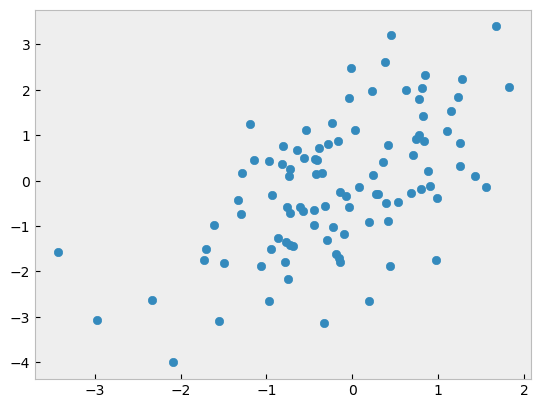

In [3]:
plt.scatter(data[:,0],data[:,1])

In [4]:
# Covariance of data
# in this case will be a 2x2 matrix
# it is always symmetric

K = np.cov(data.T)
# input to np.cov() should be a DxN

K

array([[0.96165359, 0.83463567],
       [0.83463567, 2.17959367]])

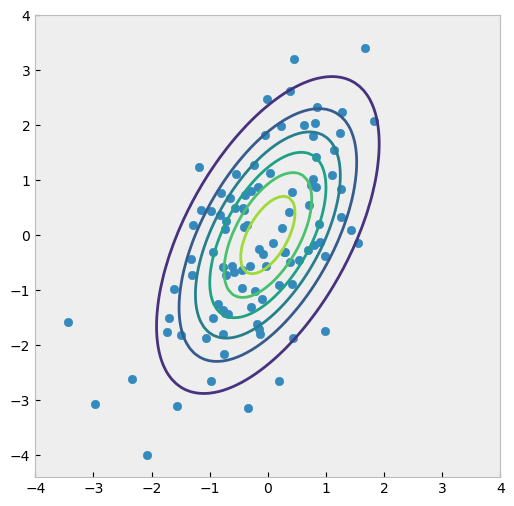

In [5]:
plot_contours(K)
plt.scatter(data[:,0],data[:,1]);

In [6]:
# Eigendecomposition

# Hermitian matrix - symmetric real matrices - covariance matrix is always hermitian

L, V = np.linalg.eigh(K)

L, V

(array([0.53744348, 2.60380378]),
 array([[-0.89146318,  0.45309314],
        [ 0.45309314,  0.89146318]]))

In [7]:
L = L[::-1]
V = V[:, ::-1]

L, V

(array([2.60380378, 0.53744348]),
 array([[ 0.45309314, -0.89146318],
        [ 0.89146318,  0.45309314]]))

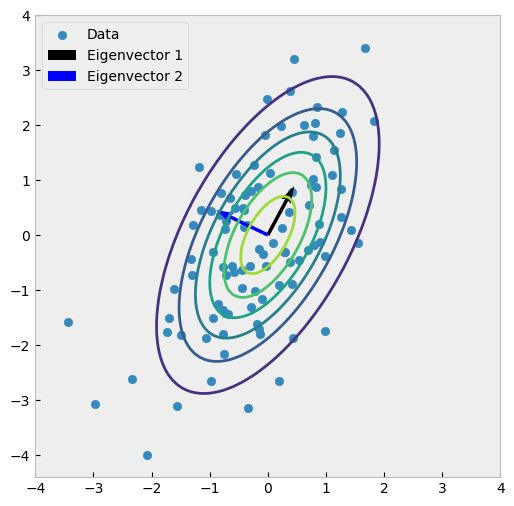

In [8]:
plot_contours(K)
plt.scatter(data[:,0],data[:,1])
plotvec(V[:,0], V[:,1])
plt.legend(['Data','Eigenvector 1', 'Eigenvector 2']);

In [9]:
# Rotate data such that new space has uncorrelated dimensions/features

rotated = V.T@data.T

rotated.shape

(2, 100)

In [10]:
# Check - compute covariance for new rotated data

K2 = np.cov(rotated)

K2

array([[2.60380378e+00, 3.28564419e-16],
       [3.28564419e-16, 5.37443485e-01]])

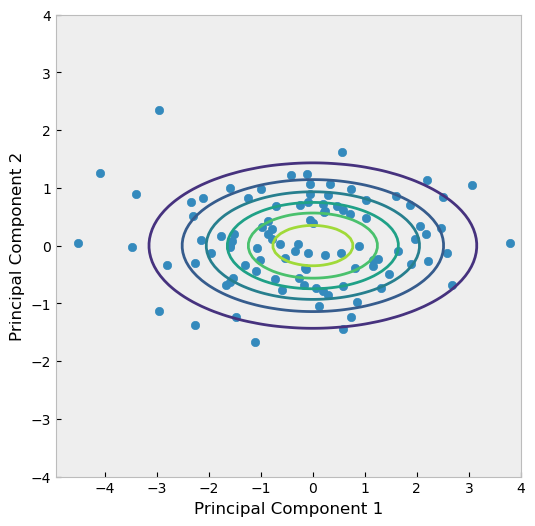

In [11]:
plot_contours(K2)
plt.scatter(rotated[0,:],rotated[1,:])
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2');

In [12]:
# Compute angle between eigenvector and 1st standard unit vector [1,0]

e1=np.array([[1],[0]])

# arccos(x.T@y/ norm(x)*norm(y))

np.degrees(np.arccos((e1.T@V[:,0])/(np.linalg.norm(e1)*np.linalg.norm(V[:,0]))))

array([63.05768978])

In [13]:
# Alternative for rotating data

rotated2 = makerot(-56.47494431)@data.T

rotated2.shape

(2, 100)

In [14]:
# Check covariance

K3 = np.cov(rotated2)

K3

array([[2.57664794, 0.2353217 ],
       [0.2353217 , 0.56459932]])

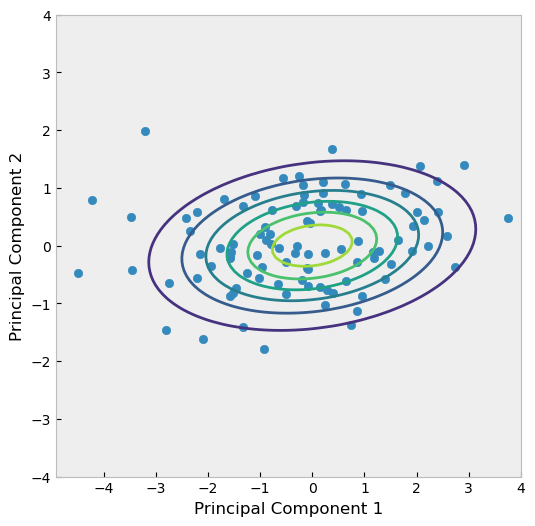

In [15]:
plot_contours(K3)
plt.scatter(rotated2[0,:],rotated2[1,:])
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2');

---

Coming back to the wine dataset:

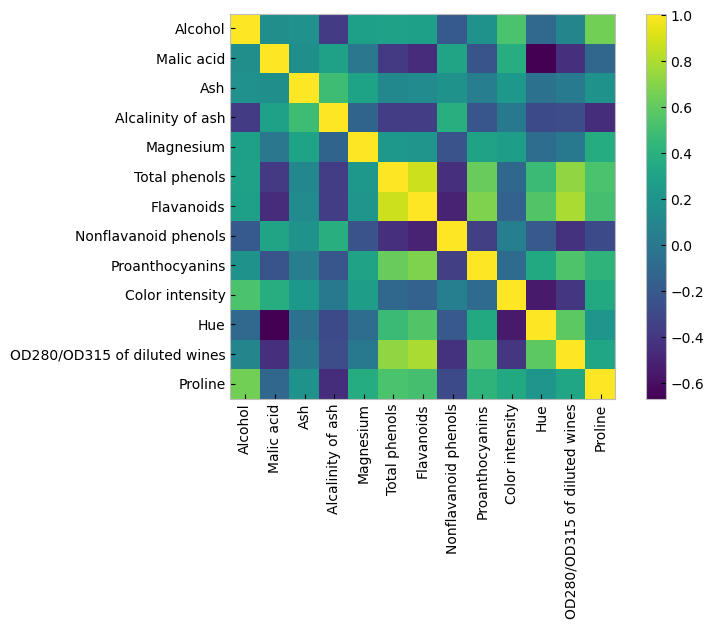

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

df_wine = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/wine/wine.data', header=None)

df_wine.columns = ['Class label', 'Alcohol',
                   'Malic acid', 'Ash',
                   'Alcalinity of ash', 'Magnesium',
                   'Total phenols', 'Flavanoids',
                   'Nonflavanoid phenols',
                   'Proanthocyanins',
                   'Color intensity', 'Hue',
                   'OD280/OD315 of diluted wines',
                   'Proline']

df_wine

t = df_wine['Class label'].values
X = df_wine.drop(['Class label'], axis=1).values

X_train, X_test, t_train, t_test = train_test_split(X, t, 
                                                    test_size=0.3, 
                                                    stratify=t)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

cov_train = np.cov(X_train.T)

plt.figure(figsize=(8,5))
plt.imshow(cov_train)
plt.colorbar()
plt.xticks(range(13),df_wine.columns[1:],rotation=90)
plt.yticks(range(13),df_wine.columns[1:]);

Building a function to implement PCA from scratch:

In [17]:
def myPCA(X, m, display=1):
    '''This function implements PCA. The data matrix X is DxN matrix, 
    where D is the dimension and N the number of points'''
    
    D, N = X.shape
    
    # Demean the Data
    data = X - X.mean(axis=1).reshape(-1, 1)
    
    # Covariance of the input data X
    cov_mat = np.cov(data)
    
    # Find eigenvectors and eigenvalues 
    eigen_vals, eigen_vecs = np.linalg.eigh(cov_mat)
    
    # Sort eigenvectors by magnitude of eigenvalues
    L = eigen_vals[::-1]
    U = eigen_vecs[:,::-1]

    # Linear transformation
    A = U[:,:m].T
    
    #compute explained variance and visualize it
    cumulative_var_exp=0
    total = sum(L)
    var_explained = [(i/total) for i in L]
    cumulative_var_exp = np.cumsum(var_explained)
    if display:
        plt.bar(range(1,D+1), var_explained, alpha=0.5, align='center', label='individual explained variance')
        plt.step(range(1,D+1), cumulative_var_exp, alpha=0.5, where='mid', label='cumulative explained variance')
        plt.ylabel('Explained variance ratio')
        plt.xlabel('Principal components')
        plt.legend(loc='best');
    return A, var_explained

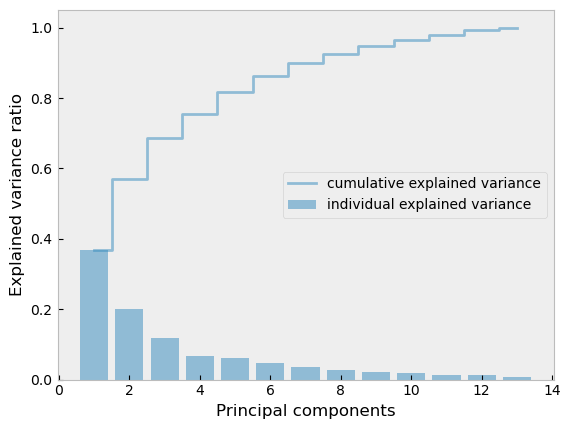

In [18]:
A, var_explained = myPCA(X_train.T, 13, display=1)

The resulting plot indicates that the first principal component alone accounts for 40 percent of the variance. Also, we can see that the first two principal components combined explain almost 60 percent of the variance in the data.

Although the explained variance plot reminds us of the feature importance, we shall remind ourselves that PCA is an unsupervised method, which means that information about the class labels is ignored.

In [19]:
X_train_pca = (A@X_train.T).T 

# the result is NxD

X_train_pca.shape

(124, 13)

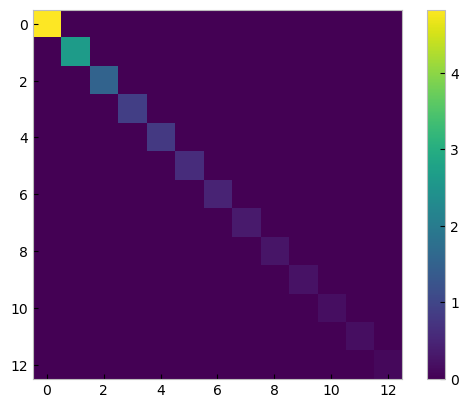

In [20]:
cov_mat = np.cov(X_train_pca.T)

plt.imshow(cov_mat)
plt.colorbar();

## PCA with ```scikit-learn```

In [21]:
from sklearn.decomposition import PCA

In [22]:
PCA?

In [23]:
pca = PCA(n_components=13)

pca

PCA(n_components=13)

In [24]:
pca.fit(X_train)

PCA(n_components=13)

In [25]:
pca.explained_variance_ratio_

array([0.36795136, 0.20137525, 0.11762017, 0.06795863, 0.06106463,
       0.04616534, 0.03676954, 0.02695632, 0.02136349, 0.01741266,
       0.01432749, 0.0137176 , 0.0073175 ])

In [26]:
np.cumsum(pca.explained_variance_ratio_)

array([0.36795136, 0.56932661, 0.68694678, 0.75490541, 0.81597005,
       0.86213539, 0.89890493, 0.92586125, 0.94722474, 0.9646374 ,
       0.97896489, 0.9926825 , 1.        ])

In [27]:
np.where(np.cumsum(pca.explained_variance_ratio_)>=0.9)

(array([ 7,  8,  9, 10, 11, 12]),)

In [28]:
# The matrix A = U.T is 

# the eigenvectors are stored in rows
pca.components_.shape

(13, 13)

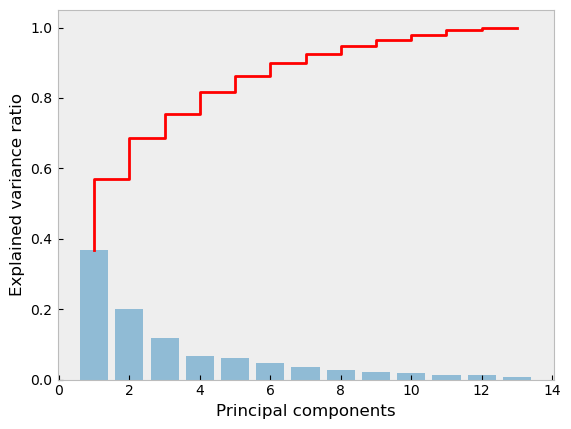

In [29]:
plt.step(range(1,14),np.cumsum(pca.explained_variance_ratio_),c='r')
plt.bar(range(1,14),pca.explained_variance_ratio_, alpha=0.5)
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal components');

In [30]:
np.where(np.cumsum(pca.explained_variance_ratio_)>=0.9)[0][0]

np.int64(7)

In [31]:
np.cumsum(pca.explained_variance_ratio_)[7]

np.float64(0.9258612461211551)

In [32]:
y_train_pca= pca.transform(X_train)

y_train_pca.shape

(124, 13)

In [33]:
# cov_mat = ##

# plt.figure(figsize=(8,5))
# plt.imshow(cov_mat)
# plt.colorbar()
# plt.xticks(range(13),df_wine.columns[1:],rotation=90)
# plt.yticks(range(13),df_wine.columns[1:]);

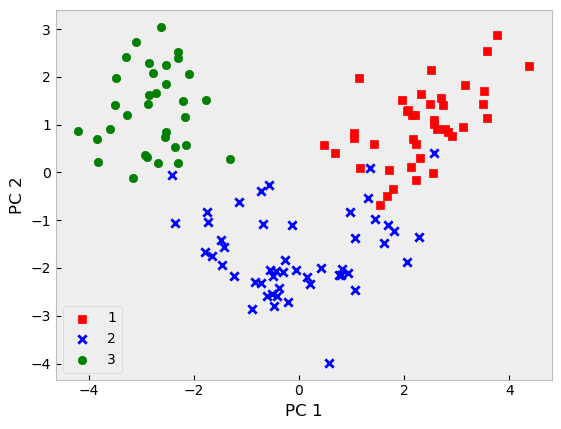

In [34]:
colors = ['r', 'b', 'g']
markers = ['s', 'x', 'o']

for l, c, m in zip(np.unique(t_train), colors, markers):
    plt.scatter(y_train_pca[t_train==l, 0], y_train_pca[t_train==l, 1],c=c, label=l, marker=m)

plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend(loc='lower left')
plt.show()

The training data is used to find the new features (eigenvectors). We can then represent the test set in this new feature space:

In [35]:
y_test_pca = pca.transform(X_test)

y_test_pca.shape

(54, 13)

---

## Example: Concentric Circles

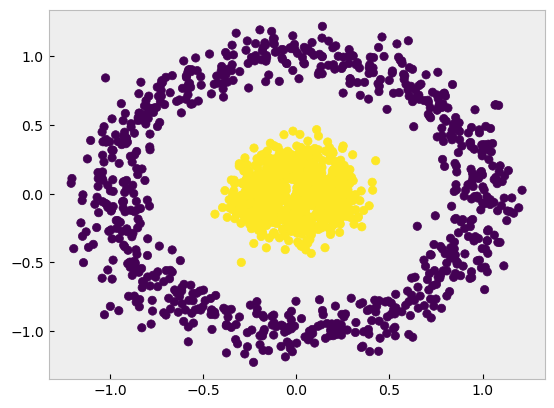

In [36]:
from sklearn.datasets import make_circles

X, y = make_circles(n_samples=1500, noise=0.1, factor=0.2)

plt.scatter(X[:,0],X[:,1],c=y);

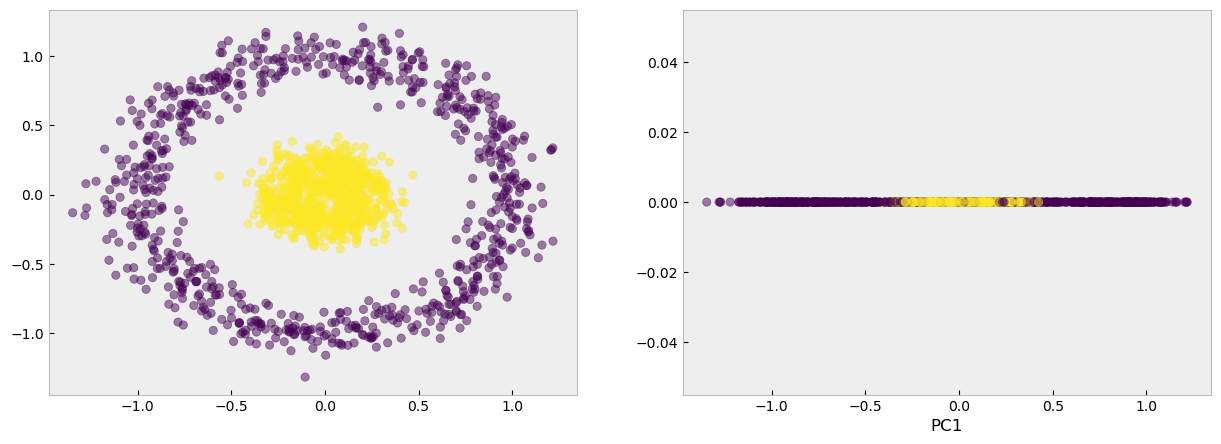

In [37]:
pca = PCA(n_components = 2)
X_spca = pca.fit_transform(X)

plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.scatter(X_spca[:,0], X_spca[:,1], c=y, alpha=0.5)
plt.subplot(1,2,2)
plt.scatter(X_spca[:,0], np.zeros(len(X_spca[:,0])), c=y, alpha=0.5)
plt.xlabel('PC1');

## Kernel PCA

There are other variants of PCA such as **Kernel PCA**, where we first project the data to a space where classes are linearly separable (RBF kernel) and then apply PCA:

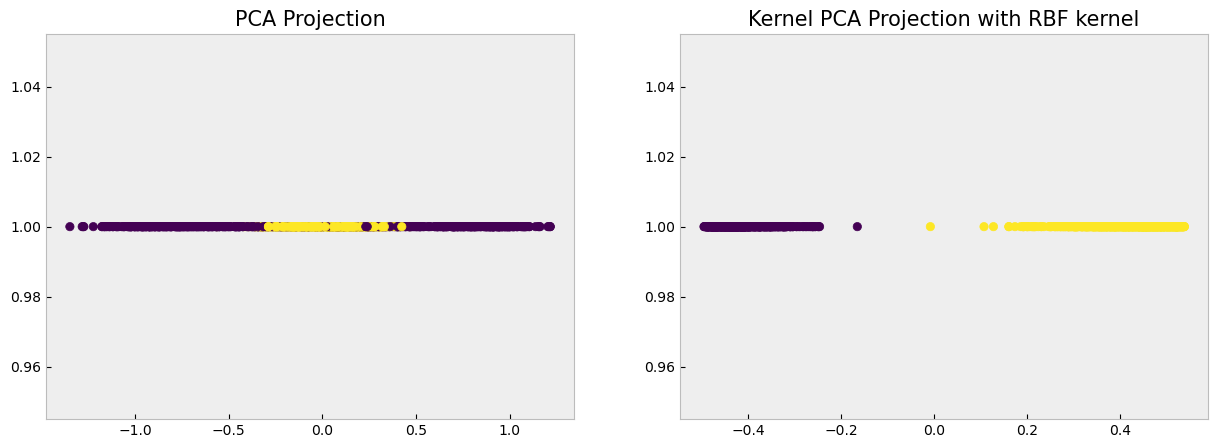

In [38]:
from sklearn.decomposition import KernelPCA

model_pca = PCA(n_components=1)
proj = model_pca.fit_transform(X)

model_kpca = KernelPCA(n_components=1,kernel='rbf',gamma=2)
proj_kpca = model_kpca.fit_transform(X)

plt.figure(figsize=(15,5))
plt.subplot(121); plt.scatter(proj,np.ones(len(proj)),c=y)
plt.title('PCA Projection', size=15)
plt.subplot(122); plt.scatter(proj_kpca,np.ones(len(proj_kpca)),c=y)
plt.title('Kernel PCA Projection with RBF kernel',size=15);

---

## PCA Eigenfaces Example

In [39]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('bmh')
plt.rcParams['axes.grid'] = False

In [40]:
from sklearn.datasets import fetch_olivetti_faces

faces = fetch_olivetti_faces(return_X_y=False)

# print(faces.DESCR)

In [41]:
X = faces.data # data matrix

t = faces.target # target label

X.shape, t.shape # 400 images, each of size 64x64=4096 pixels

((400, 4096), (400,))

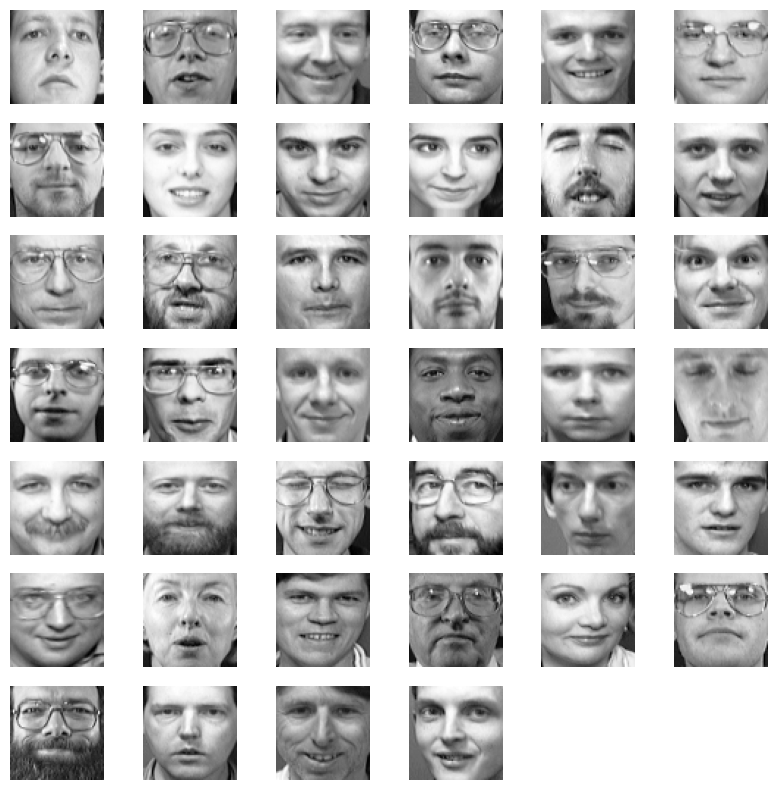

In [42]:
fig = plt.figure(figsize=(10,10))
for i in range(40):
    fig.add_subplot(7,6,i+1)
    idx = np.random.choice(np.where(t==i)[0])
    plt.imshow(X[idx,:].reshape(64,64), cmap='gray')
    plt.axis('off')

In [43]:
np.unique(t, return_counts=True)

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
        34, 35, 36, 37, 38, 39]),
 array([10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
        10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
        10, 10, 10, 10, 10, 10]))

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, t_train, t_test = train_test_split(X, t, 
                                                    test_size=0.2, 
                                                    random_state=42)

X_train.shape, t_train.shape, X_test.shape, t_test.shape

((320, 4096), (320,), (80, 4096), (80,))

In [45]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

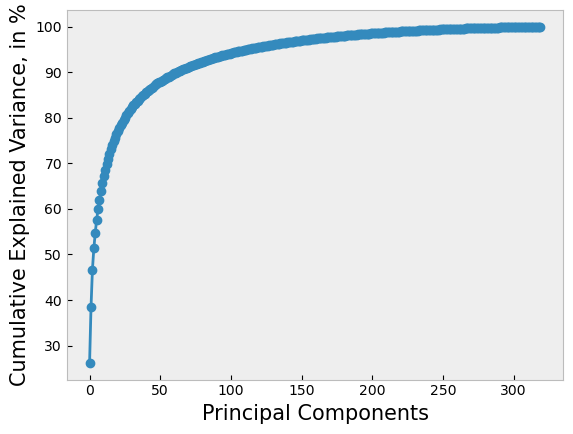

In [46]:
pca = PCA(n_components=320)
pca.fit(X_train_scaled)

plt.plot(100*np.cumsum(pca.explained_variance_ratio_), '-o')
plt.xlabel('Principal Components',size=15)
plt.ylabel('Cumulative Explained Variance, in %', size=15);

In [47]:
np.where(np.cumsum(pca.explained_variance_ratio_)>=0.9)

(array([ 62,  63,  64,  65,  66,  67,  68,  69,  70,  71,  72,  73,  74,
         75,  76,  77,  78,  79,  80,  81,  82,  83,  84,  85,  86,  87,
         88,  89,  90,  91,  92,  93,  94,  95,  96,  97,  98,  99, 100,
        101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113,
        114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126,
        127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139,
        140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152,
        153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165,
        166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178,
        179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191,
        192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204,
        205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217,
        218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230,
        231, 232, 233, 234, 235, 236, 237, 238, 239

In [48]:
np.cumsum(pca.explained_variance_ratio_)[62]

np.float32(0.90058786)

In order to explain 90% of the variance in the data, we need to preserve 63 principal components.

Let's project to 2-D so we can plot it:

In [49]:
pca = PCA(n_components=2)

ypca = pca.fit_transform(X_train_scaled)

ypca.shape

(320, 2)

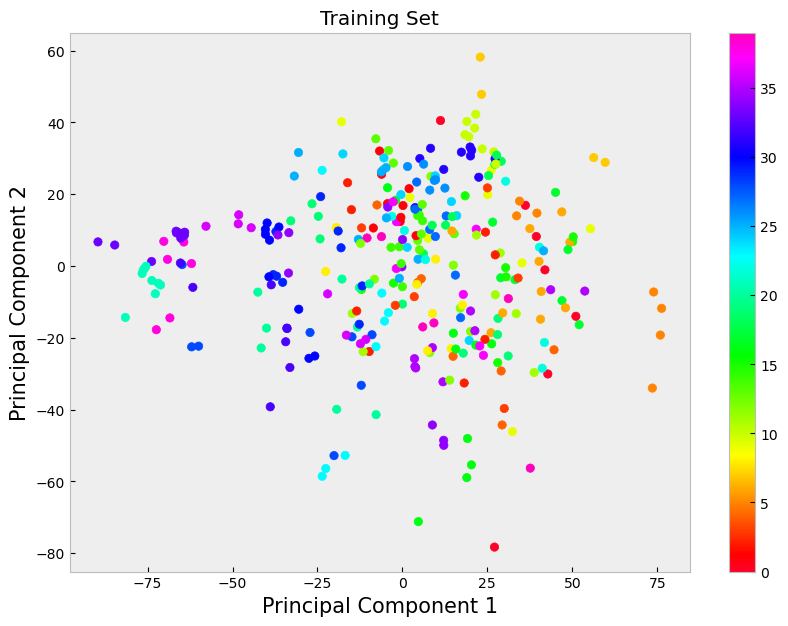

In [50]:
plt.figure(figsize=(10,7))
plt.scatter(ypca[:,0], ypca[:,1], c=t_train, cmap=plt.cm.gist_rainbow)
plt.xlabel('Principal Component 1', size=15)
plt.ylabel('Principal Component 2', size=15)
plt.title('Training Set')
plt.colorbar();

In [51]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

# LDA is a supervised linear dimensionality reduction algorithm 

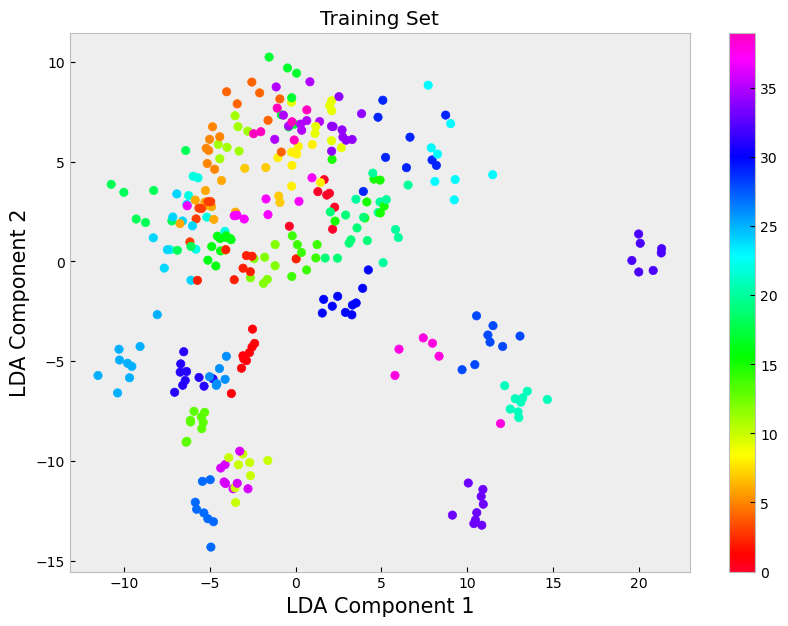

In [52]:
lda = LDA(n_components=2)

ylda = lda.fit_transform(X_train_scaled, t_train)

plt.figure(figsize=(10,7))
plt.scatter(ylda[:,0], ylda[:,1], c=t_train, cmap=plt.cm.gist_rainbow)
plt.xlabel('LDA Component 1', size=15)
plt.ylabel('LDA Component 2', size=15)
plt.title('Training Set')
plt.colorbar();

Not that the 40 classes are overlapping in the linear projection space. This is because PCA is **unsupervised**, it does use the class labels *anywhere* in finding the matrix for linear projection.

To apply this transformation in the test set, simply multiply the resultant modal matrix with the scaled test set:

In [53]:
# Transform the test set using the linear transformation found with the training data

ypca_test = pca.transform(X_test_scaled)

ypca_test.shape

(80, 2)

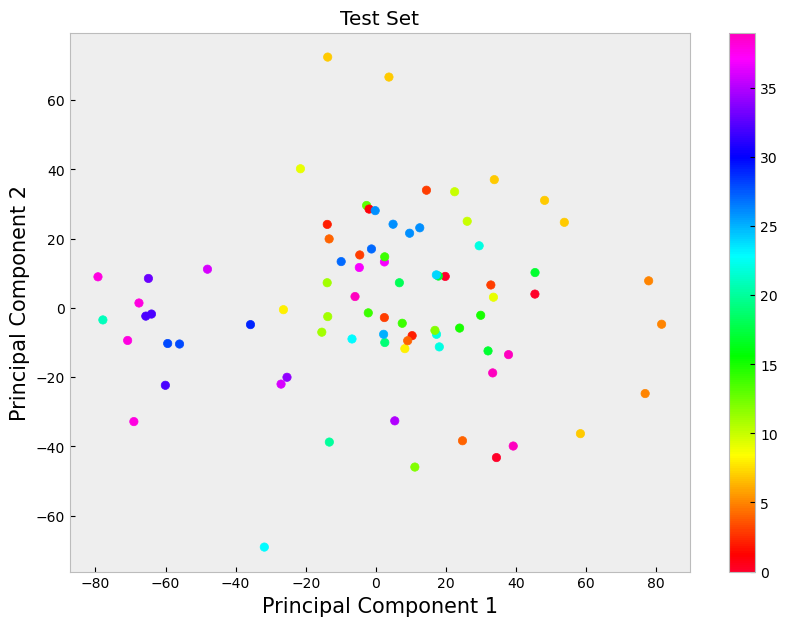

In [54]:
plt.figure(figsize=(10,7))
plt.scatter(ypca_test[:,0], ypca_test[:,1], c=t_test, cmap=plt.cm.gist_rainbow)
plt.xlabel('Principal Component 1', size=15)
plt.ylabel('Principal Component 2', size=15)
plt.title('Test Set')
plt.colorbar();

You can access the linear transformation $\mathbf{A} = \mathbf{U}^T$ using the method ```components_```:

In [55]:
# This contains a matrix with eigenvectors in its rows

A = pca.components_

A.shape

(2, 4096)

Note that the eigenvectors are described in the original space, that is, they are 4096-dimensional!

Since we are working with images, we can reshape them back to a $64 \times 64$ image and see what are the regions in the image with maximum explained variance! This is called the **eigenfaces**.

In [56]:
yyy = X_test_scaled@A.T

yyy.shape

(80, 2)

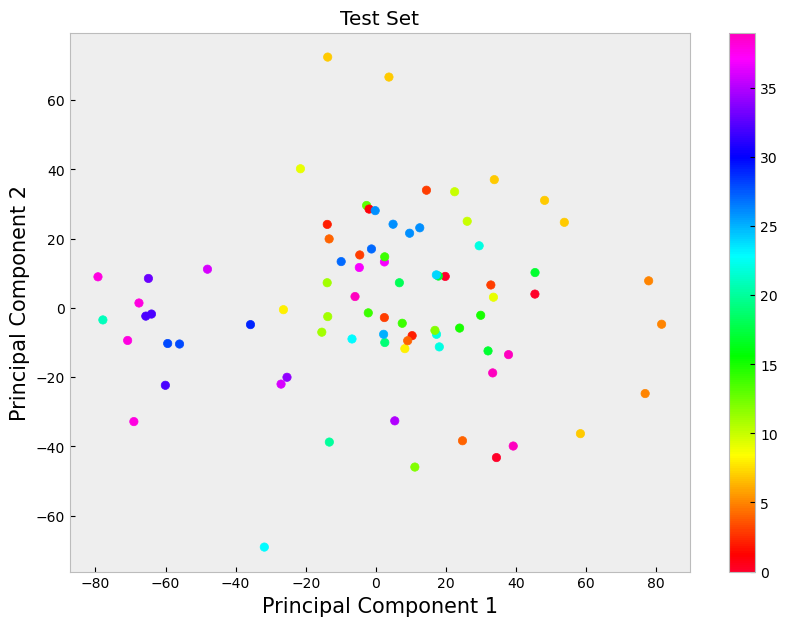

In [57]:
plt.figure(figsize=(10,7))
plt.scatter(yyy[:,0], yyy[:,1], c=t_test, cmap=plt.cm.gist_rainbow)
plt.xlabel('Principal Component 1', size=15)
plt.ylabel('Principal Component 2', size=15)
plt.title('Test Set')
plt.colorbar();

Let's visualize the first eigenvector (the one associated with the largest eigenvalue):

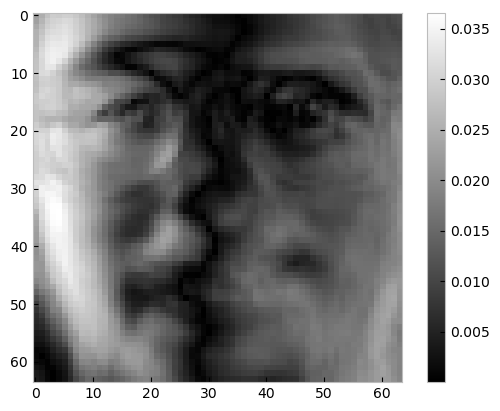

In [58]:
plt.imshow(abs(pca.components_[1,:].reshape(64,64)), cmap='gray')
plt.colorbar();

Let's now recover 16 eigenvectors and plot them as images:

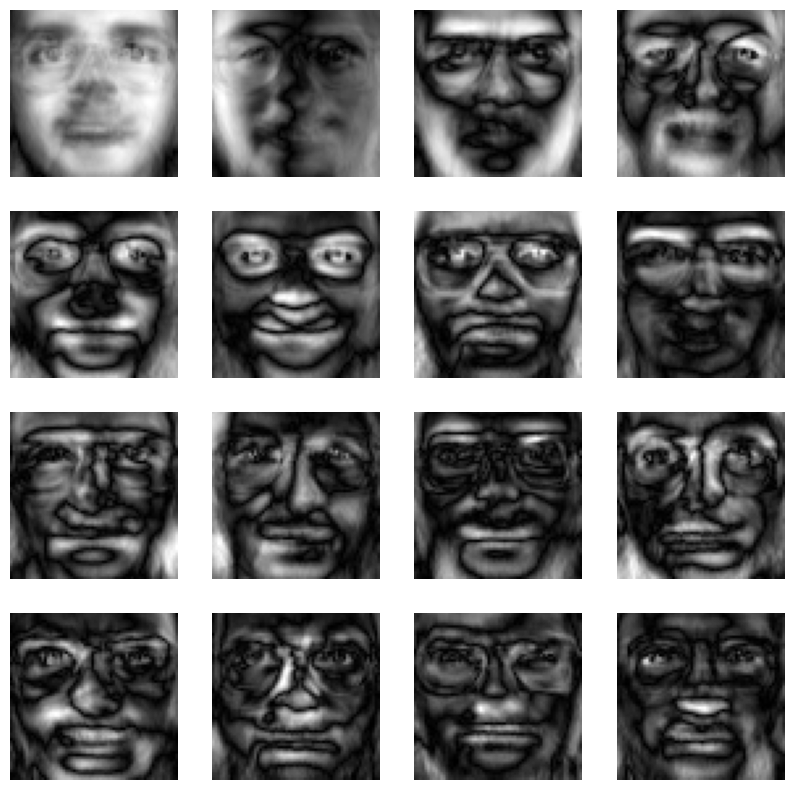

In [59]:
n_components = 16

pca = PCA(n_components=n_components)
ypca = pca.fit_transform(X_train_scaled)

fig=plt.figure(figsize=(10,10))
for i in range(n_components):
    fig.add_subplot(4,4,i+1)
    plt.imshow(abs(pca.components_[i,:].reshape(64,64)),cmap='gray')
    plt.axis('off')

The eigenvectors are describing the regions in the 64x64 image that explain the most variance. the more eigenvectors are kept, the better a reconstruction image will be produced.

For example, let's reconstruct the images in the dataset using the top 16 eigenvectors:

In [60]:
# Covariance matrix for training data
K = np.cov(X_train_scaled.T) # np.cov() expects the input to be DxN matrix

# Eigendecomposition
L, U = np.linalg.eigh(K)

L

array([-1.49956076e-13, -1.24002575e-13, -9.83409059e-14, ...,
        3.38660292e+02,  4.99392055e+02,  1.07742245e+03])

In [61]:
U = U[:,::-1] # Flipping order of eigenvectors

L = np.diag(L[::-1]) # Flip the eigenvalues and construct a diagonal matrix

In [62]:
N_eigenvectors = 9

# Projection/Transformation matrix
P = U[:,:N_eigenvectors]

# PCA project 
X_proj = X_train_scaled@P

# Reconstructing the original images using only 9 eigenvectors
X_reconstruct = X_proj@np.linalg.pinv(P)

X_reconstruct.shape

(320, 4096)

Since the projection is given by:

$$\mathbf{Y} = \mathbf{A}\mathbf{X}$$

In order to recover $\mathbf{X}$, we need to left-multiply by the pseudo-inverse of $\mathbf{A}$:

$$\hat{\mathbf{X}} = \mathbf{A}^\dagger\mathbf{Y}$$

In [63]:
# Alternatively
pca = PCA(n_components=9)
ypca = pca.fit_transform(X_train_scaled)
X_reconstruct_skl = pca.inverse_transform(ypca)

X_reconstruct_skl.shape

(320, 4096)

We also need to bringing back to the original scaling: multiplying by the standard deviation and adding the sample mean value:

In [64]:
X_reconstructed = scaler.inverse_transform(X_reconstruct)

X_reconstructed_skl = scaler.inverse_transform(X_reconstruct_skl)


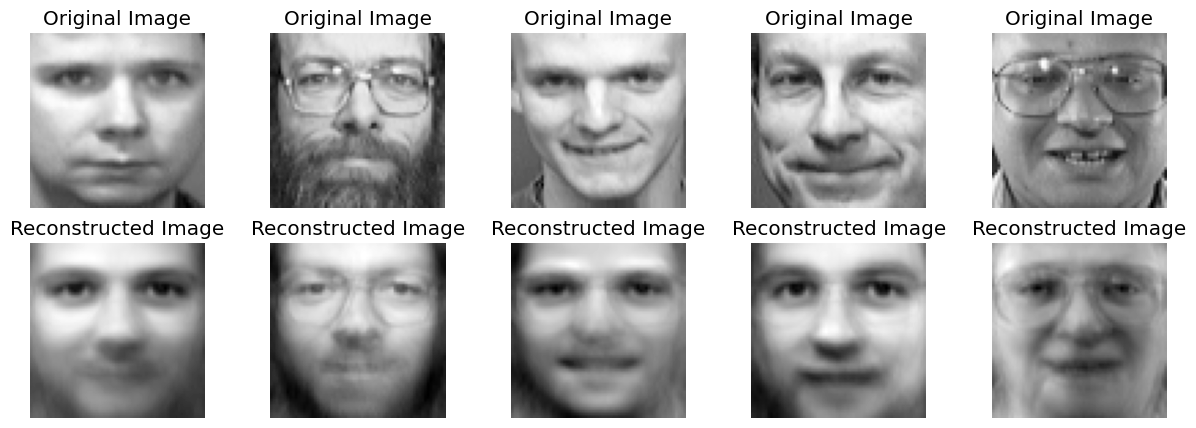

In [65]:
N = 5
idx = np.random.choice(range(X_reconstructed.shape[0]),replace=False,size=N)

fig = plt.figure(figsize=(15,5))

j=1
for i in range(N):
    fig.add_subplot(2,N,j)
    plt.imshow(X_train[idx[i],:].reshape(64,64), cmap='gray')
    plt.axis('off')
    plt.title('Original Image');

    fig.add_subplot(2,N,j+N)
    plt.imshow(X_reconstructed[idx[i],:].reshape(64,64), cmap='gray')
    plt.axis('off')
    plt.title('Reconstructed Image');
    j+=1

In [66]:
np.cumsum(pca.explained_variance_ratio_)

array([0.26222062, 0.3837615 , 0.4661839 , 0.51325184, 0.54706043,
       0.5768044 , 0.5999967 , 0.6201292 , 0.63931274], dtype=float32)

Putting it all together:

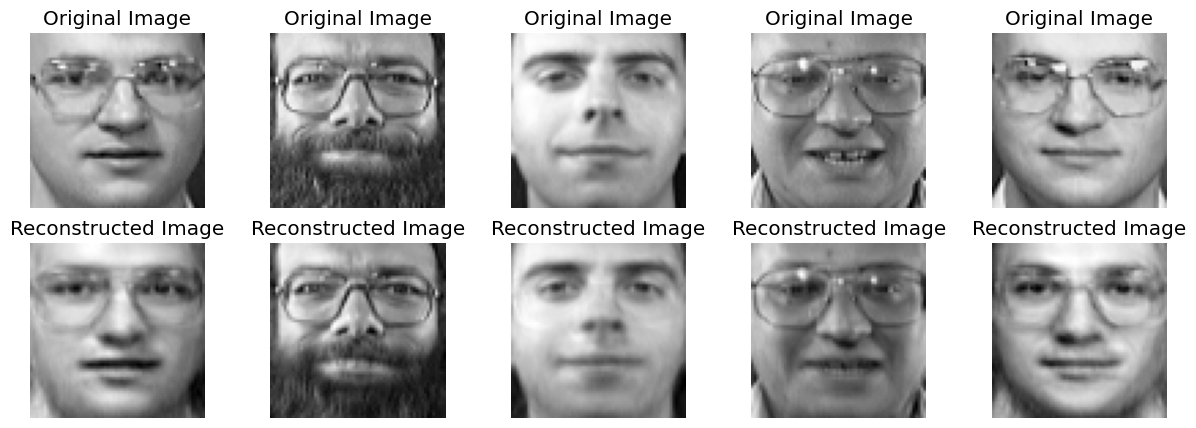

In [67]:
N_eigenvectors = 63

pca = PCA(n_components=N_eigenvectors)
ypca = pca.fit_transform(X_train_scaled)
X_reconstruct = pca.inverse_transform(ypca)
X_reconstructed = scaler.inverse_transform(X_reconstruct)

N = 5

fig = plt.figure(figsize=(15,5))
idx = np.random.choice(range(X_reconstructed.shape[0]),replace=False,size=N)
j=1
for i in range(N):
    fig.add_subplot(2,N,j)
    plt.imshow(X_train[idx[i],:].reshape(64,64), cmap='gray')
    plt.axis('off')
    plt.title('Original Image');

    fig.add_subplot(2,N,j+N)
    plt.imshow(X_reconstructed[idx[i],:].reshape(64,64), cmap='gray')
    plt.axis('off')
    plt.title('Reconstructed Image');
    j+=1

Still some compression loss but much better representation!

---

# Manifold Learning

As we have already noted, many natural sources of data correspond to low-dimensional, possibly noisy, non-linear manifolds embedded within the higher dimensional observed data space. Capturing this property explicitly can lead to improved density modeling compared with more general methods.



<span style="color:blue; font-size:20px;">**PCA and LDA are often used to project a data set onto a lower-dimensional space. However both of them assume that the data samples live in an underlying linear manifold.**</span>




There are other dimensionality reduction techniques that do not assume the manifold is linear. They include:
1. Multi-Dimensional Scaling (MDS)
2. Isometric Mapping (ISOMAP)
3. Locally Linear Embedding (LLE)
---

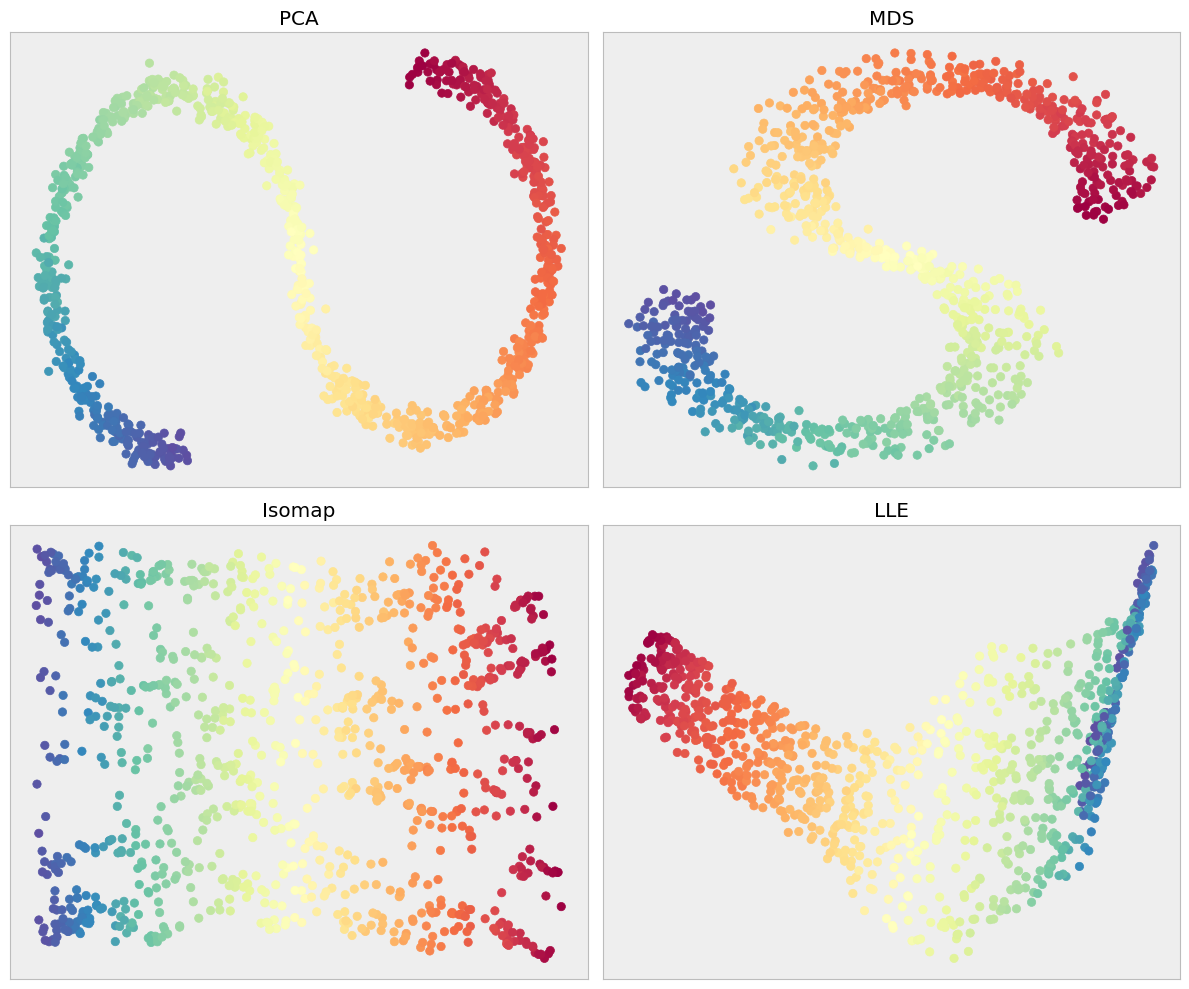

In [68]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_s_curve
from sklearn.decomposition import PCA
from sklearn.manifold import MDS, Isomap, LocallyLinearEmbedding

# Generate S-curve data
X, t = make_s_curve(n_samples=1000, noise=0.05)
color = t

# Initialize models
pca = PCA(n_components=2)
mds = MDS(n_components=2, random_state=42)
isomap = Isomap(n_components=2, n_neighbors=10)
lle = LocallyLinearEmbedding(n_components=2, n_neighbors=10, method='standard')

# Fit and transform
X_pca = pca.fit_transform(X)
X_mds = mds.fit_transform(X)
X_isomap = isomap.fit_transform(X)
X_lle = lle.fit_transform(X)

# Plot them all
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
plt.style.use('bmh')

axes[0, 0].scatter(X_pca[:, 0], X_pca[:, 1], c=color, cmap=plt.cm.Spectral)
axes[0, 0].set_title("PCA")

axes[0, 1].scatter(X_mds[:, 0], X_mds[:, 1], c=color, cmap=plt.cm.Spectral)
axes[0, 1].set_title("MDS")

axes[1, 0].scatter(X_isomap[:, 0], X_isomap[:, 1], c=color, cmap=plt.cm.Spectral)
axes[1, 0].set_title("Isomap")

axes[1, 1].scatter(X_lle[:, 0], X_lle[:, 1], c=color, cmap=plt.cm.Spectral)
axes[1, 1].set_title("LLE")

for ax in axes.flat:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()


---

# Multi-Dimensional Scaling (MDS)

Another linear technique with a similar aim is **multidimensional scaling**, or **MDS**. It finds a low-dimensional projection of the data such as to **preserve the pairwise distances between data points**, and involves finding the eigenvectors of the distance matrix. 

<span style="color:blue; font-size:20px;">Imagine you have a bunch of cities and distances between them on a messy map, and you want to redraw the map on flat paper but keep the distances as close as possible.
**MDS** tries to keep the pairwise distances between points the same when squashing from high to low dimensions.
Works well if the data’s shape is not too twisted.
**Difference from PCA:** PCA cares about directions of variance; MDS cares about distances between points.</span>



---

# Isometric feature Mapping (ISOMAP)

In **Isometric feature Mapping**, or **ISOMAP**, the goal is to project the data to a lower-dimensional space using MDS, but where the distance/dissimilarities are defined in terms of the **geodesic distances** measured along the manifold.

ISOMAP was introduced in 2000 in a [Science](https://science.sciencemag.org/content/290/5500/2319/tab-pdf) issue paper and approaches dimensionality reduction for data that lies on a manifold.

* It builds on MDS by using a specific distance: geodesic distances.

* The contribution of ISOMAP is that the proximity matrix, $D$, is constructed using **geodesic distances**.


<span style="color:blue; font-size:20px;">Imagine walking around a mountain trail. Straight-line (Euclidean) distance to the summit might be short, but you have to walk the winding path.
**Isomap** understands that: it uses the “walking distance” (geodesic distance), not straight-line distance.
It’s great for unfolding curved shapes (like the Swiss roll) into something flat while keeping the real structure.
**Difference from PCA and MDS:** It doesn't just flatten data; it unfolds data by respecting the twist and turns in the geometry.</span>


---

# Locally Linear Embedding (LLE)

**Locally linear embedding**, or **LLE** first computes the set of coefficients that best reconstructs each data point from its neighbors. These coefficients are arranged to be invariant to rotations, translations, and scalings of that data point and its neighbors, and hence they characterize the local geometrical properties of the neighborhood.

* LLE was also introduced in 2000 in the same [Science](https://science.sciencemag.org/content/290/5500/2323/tab-pdf) issue as ISOMAP.

* The intuition behind LLE is that each data point and its close neighbors lie on or close to a *locally linear* patch of the manifold.
    * We can characterize the local geometry of these patches by linear coefficients that reconstruct each data point from its neighbors.

* Each point can be written as a linear combination of its neighbors. 

* The lower-dimensional projection will be a combination of locally linear patches.


<span style="color:blue; font-size:20px;">Think of a jigsaw puzzle. Each piece fits nicely with its neighbors. **LLE** figures out how each point relates to its nearby points and tries to keep those relationships intact.
It’s very good at preserving tiny local neighborhoods, even if the global shape is super complicated.
**Difference from PCA/MDS/Isomap:** LLE focuses on local geometry, not global distances.</span>


---